# ML - BOSQUE ALEATORIO

In [74]:
import numpy as np
import pandas as pd
import pickle
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from utils1 import get_classifier_metrics
from sklearn.model_selection import GridSearchCV
import seaborn as sns
import matplotlib.pyplot as plt


## Paso 1. Lectura del conjunto de datos procesado

In [2]:
# Cargamos los dataframes 
with open('../models/04_df_invalids_removed.pkl', 'rb') as f:
    df_invalids_removed = pickle.load(f)

with open('../models/04_df_invalids_mode.pkl', 'rb') as f:
    df_invalids_mode = pickle.load(f)

with open('../models/04_df_invalids_knn.pkl', 'rb') as f:
    df_invalids_knn = pickle.load(f)

## Paso 2. Split

In [5]:
X_invalids_removed = df_invalids_removed.drop('Outcome', axis= 1)
y_invalids_removed = df_invalids_removed['Outcome']

X_invalids_mode= df_invalids_mode.drop('Outcome', axis= 1)
y_invalids_mode = df_invalids_mode['Outcome']

X_invalids_knn= df_invalids_knn.drop('Outcome', axis= 1)
y_invalids_knn = df_invalids_knn['Outcome']

X_train_1, X_test_1, y_train_1, y_test_1 = train_test_split(X_invalids_removed, y_invalids_removed, test_size=0.2, random_state=21)
X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(X_invalids_mode, y_invalids_mode, test_size=0.2, random_state=21)
X_train_3, X_test_3, y_train_3, y_test_3 = train_test_split(X_invalids_knn, y_invalids_knn, test_size=0.2, random_state=21)

## Paso 3. Modelado y Ajuste

In [7]:
model_rf_default_1 = RandomForestClassifier(random_state = 21)
model_rf_default_1.fit(X_train_1, y_train_1)

model_rf_default_2 = RandomForestClassifier(random_state = 21)
model_rf_default_2.fit(X_train_2, y_train_2)

model_rf_default_3 = RandomForestClassifier(random_state = 21)
model_rf_default_3.fit(X_train_3, y_train_3)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## Paso 4. Predicción

In [8]:
y_pred_test_1 = model_rf_default_1.predict(X_test_1)
y_pred_train_1 = model_rf_default_1.predict(X_train_1)

y_pred_test_2 = model_rf_default_2.predict(X_test_2)
y_pred_train_2 = model_rf_default_2.predict(X_train_2)

y_pred_test_3 = model_rf_default_3.predict(X_test_3)
y_pred_train_3 = model_rf_default_3.predict(X_train_3)

In [11]:
get_classifier_metrics(y_pred_test_1, y_test_1, y_pred_train_1, y_train_1, average="weighted")

,Accuracy,F1 Score,Precision,Recall
Train set,1.000000,1.000000,1.000000,1.000000
Test set,0.772152,0.753074,0.779837,0.772152


In [16]:
get_classifier_metrics(y_pred_test_2, y_test_2, y_pred_train_2, y_train_2, average="weighted")

,Accuracy,F1 Score,Precision,Recall
Train set,1.00000,1.000000,1.000000,1.00000
Test set,0.74026,0.724711,0.744602,0.74026


In [80]:
df3 = get_classifier_metrics(y_pred_test_3, y_test_3, y_pred_train_3, y_train_3, average="weighted")
df3

,Accuracy,F1 Score,Precision,Recall
Train set,1.000000,1.000000,1.000000,1.000000
Test set,0.746753,0.734555,0.748324,0.746753


### Modelo optimizado con los hiperparámetros `n_estimators` y `bootstrap`

In [34]:
model_rf_opt_1 = RandomForestClassifier(n_estimators = 50, bootstrap=False, random_state = 21)
model_rf_opt_1.fit(X_train_1, y_train_1)

model_rf_opt_2 = RandomForestClassifier(n_estimators = 25, bootstrap=False, random_state = 21)
model_rf_opt_2.fit(X_train_2, y_train_2)

model_rf_opt_3 = RandomForestClassifier(n_estimators = 25, bootstrap=False, random_state = 21)
model_rf_opt_3.fit(X_train_3, y_train_3)

,n_estimators,25
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,False
,oob_score,False


In [35]:
y_pred_test_opt_1 = model_rf_opt_1.predict(X_test_1)
y_pred_train_opt_1 = model_rf_opt_1.predict(X_train_1)

y_pred_test_opt_2 = model_rf_opt_2.predict(X_test_2)
y_pred_train_opt_2 = model_rf_opt_2.predict(X_train_2)

y_pred_test_opt_3 = model_rf_opt_3.predict(X_test_3)
y_pred_train_opt_3 = model_rf_opt_3.predict(X_train_3)

In [36]:
get_classifier_metrics(y_pred_test_opt_1, y_test_1, y_pred_train_opt_1, y_train_1, average="weighted")

,Accuracy,F1 Score,Precision,Recall
Train set,1.000000,1.000000,1.000000,1.000000
Test set,0.746835,0.719919,0.755209,0.746835


In [37]:
get_classifier_metrics(y_pred_test_opt_2, y_test_2, y_pred_train_opt_2, y_train_2, average="weighted")

,Accuracy,F1 Score,Precision,Recall
Train set,1.000000,1.000000,1.000000,1.000000
Test set,0.720779,0.705193,0.720262,0.720779


In [38]:
get_classifier_metrics(y_pred_test_opt_3, y_test_3, y_pred_train_opt_3, y_train_3, average="weighted")

,Accuracy,F1 Score,Precision,Recall
Train set,1.000000,1.000000,1.000000,1.000000
Test set,0.714286,0.701558,0.710459,0.714286


### Modelo optimizado con los hiperparámetros con `GridSearchCV`

In [61]:
param_grid = {'n_estimators': [50, 60],
              'criterion': ['gini', 'entropy'],
              'max_depth': [5, 10, None],
              'min_samples_split': [2, 5],
              'min_samples_leaf': [1, 2],
              'max_features': ['sqrt', 'log2']}
              #'bootstrap' : [True, False]}

grid_1 = GridSearchCV(model_rf_default_1,
                    param_grid,
                    scoring='f1',
                    cv=5)

grid_2 = GridSearchCV(model_rf_default_2,
                    param_grid,
                    scoring='f1',
                    cv=5)

grid_3 = GridSearchCV(model_rf_default_3,
                    param_grid,
                    scoring='f1',
                    cv=5)


In [65]:
# Entrenamos el grid con los hiperparametros
grid_1.fit(X_train_1, y_train_1)
#Devuelvemos los mejores parametros despues de entrenarlo
grid_1.best_params_

{'criterion': 'entropy',
 'max_depth': 10,
 'max_features': 'log2',
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'n_estimators': 60}

In [66]:
# Entrenamos el grid con los hiperparametros
grid_2.fit(X_train_2, y_train_2)
#Devuelvemos los mejores parametros despues de entrenarlo
grid_2.best_params_

{'criterion': 'gini',
 'max_depth': 10,
 'max_features': 'sqrt',
 'min_samples_leaf': 2,
 'min_samples_split': 2,
 'n_estimators': 50}

In [67]:
# Entrenamos el grid con los hiperparametros
grid_3.fit(X_train_3, y_train_3)
#Devuelvemos los mejores parametros despues de entrenarlo
grid_3.best_params_

{'criterion': 'gini',
 'max_depth': 10,
 'max_features': 'sqrt',
 'min_samples_leaf': 2,
 'min_samples_split': 2,
 'n_estimators': 50}

In [68]:
#Modelos con los mejores parametros
grid_rf_1 = grid_1.best_estimator_
grid_rf_2 = grid_2.best_estimator_
grid_rf_3 = grid_3.best_estimator_

In [69]:
# Repetimos el entrenamiento pero ahora con el grid que tiene los hiperparametros establecidos
grid_rf_1.fit(X_train_1, y_train_1)
grid_rf_2.fit(X_train_2, y_train_2)
grid_rf_3.fit(X_train_3, y_train_3)

,n_estimators,50
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [70]:
y_pred_test_1_grid = grid_rf_1.predict(X_test_1)
y_pred_train_1_grid = grid_rf_1.predict(X_train_1)

y_pred_test_2_grid = grid_rf_2.predict(X_test_2)
y_pred_train_2_grid = grid_rf_2.predict(X_train_2)

y_pred_test_3_grid = grid_rf_3.predict(X_test_3)
y_pred_train_3_grid = grid_rf_3.predict(X_train_3)

In [ ]:
metrics_grid_1 = get_classifier_metrics(y_pred_test_1_grid, y_pred_test_1, y_pred_train_1_grid, y_train_1, average="weighted")
metrics_grid_1


,Accuracy,F1 Score,Precision,Recall
Train set,1.000000,1.000000,1.000000,1.000000
Test set,0.936709,0.937415,0.938534,0.936709


In [83]:
metrics_grid_2 = get_classifier_metrics(y_pred_test_2_grid, y_pred_test_2, y_pred_train_2_grid, y_train_2, average="weighted")
metrics_grid_2

,Accuracy,F1 Score,Precision,Recall
Train set,0.947883,0.947269,0.948531,0.947883
Test set,0.948052,0.947612,0.947586,0.948052


In [84]:
metrics_grid_3 = get_classifier_metrics(y_pred_test_3_grid, y_pred_test_3, y_pred_train_3_grid, y_train_3, average="weighted")
metrics_grid_3

,Accuracy,F1 Score,Precision,Recall
Train set,0.954397,0.95399,0.954715,0.954397
Test set,0.954545,0.95398,0.954360,0.954545


/tmp/ipykernel_6934/873177211.py:17: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=metrics_long, x='Métrica', y='Valor', hue='Modelo', ci=None)


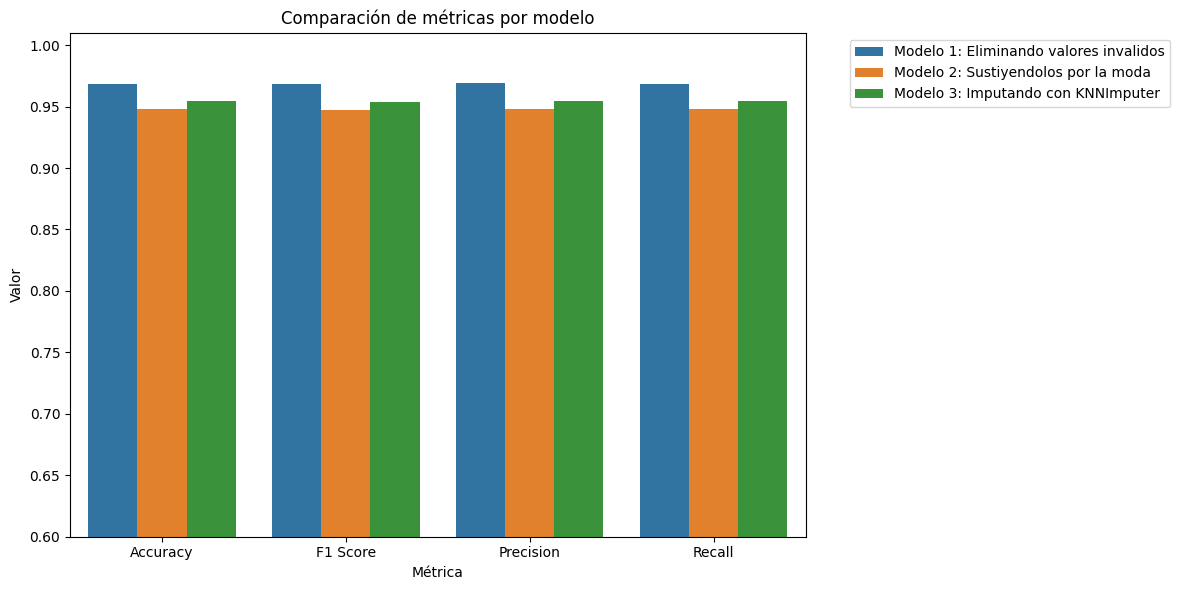

In [88]:
# 2. Añadir nombre del modelo
metrics_grid_1['Modelo'] = 'Modelo 1: Eliminando valores invalidos'
metrics_grid_2['Modelo'] = 'Modelo 2: Sustiyendolos por la moda'
metrics_grid_3['Modelo'] = 'Modelo 3: Imputando con KNNImputer'

# 3. Combinar en un solo DataFrame
metrics_all = pd.concat([metrics_grid_1, metrics_grid_2, metrics_grid_3]).reset_index().rename(columns={'index': 'Conjunto'})

# 4. Convertir a formato largo
metrics_long = metrics_all.melt(id_vars=['Conjunto', 'Modelo'],
                                value_vars=['Accuracy', 'F1 Score', 'Precision', 'Recall'],
                                var_name='Métrica',
                                value_name='Valor')

# 5. Graficar
plt.figure(figsize=(12, 6))
sns.barplot(data=metrics_long, x='Métrica', y='Valor', hue='Modelo', ci=None)
plt.title('Comparación de métricas por modelo')
plt.ylim(0.6, 1.01)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
